In [1]:
from pyvtna.vtna import VTNA, order_search, normalize_time
from pyvtna.testing import simulate_reaction_trace
import numpy as np
import matplotlib.pyplot as plt

## Generating Dummy Data

For testing purposes, let's generate some fake data for the reaction:

$$2NO + O_2 \longrightarrow 2NO_2,  Rate=k[NO]^2[O_2]$$

We don't care about absolute rates, so we will just set k = 1

In [17]:
time = np.linspace(0, 1600, 1600)
k = 0.001

# order reactants as [NO, O2]
reac_st = [2., 1.]
reac_orders = [2, 1]
reac_coefs = [2., 1.]
prod_st = [0.]
prod_coefs = [2]
noise = 0.0

[NO, O2], [NO2] = simulate_reaction_trace(time, reac_st, reac_orders, reac_coefs, 
                                           prod_st, prod_coefs, k=k, noise=noise)

## Differing Starting Concentrations
Now let's simulate a second run of the reaction, but with the starting concentration of NO doubled, as if running a series of rate experiments

In [18]:
time2 = np.linspace(0, 1400, 1400)
reac_st = [3., 1.]
[NO_b, O2_b], [NO2_b] = simulate_reaction_trace(time2, reac_st, reac_orders, reac_coefs, 
                                                prod_st, prod_coefs, k=k, noise=noise)

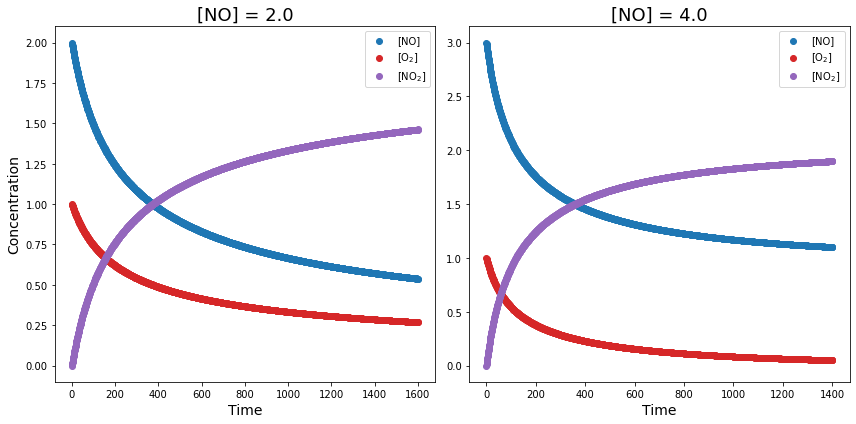

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(time, NO, c='tab:blue', label="[NO]")
ax1.scatter(time, O2, c='tab:red', label="[O$_2$]")
ax1.scatter(time, NO2, c='tab:purple', label="[NO$_2$]")
ax1.legend()
ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Concentration', fontsize=14)
ax1.set_title('[NO] = 2.0', fontsize=18)

ax2.scatter(time2, NO_b, c='tab:blue', label="[NO]")
ax2.scatter(time2, O2_b, c='tab:red', label="[O$_2$]")
ax2.scatter(time2, NO2_b, c='tab:purple', label="[NO$_2$]")
ax2.legend()
ax2.set_xlabel('Time', fontsize=14)
ax2.set_title('[NO] = 4.0', fontsize=18)

plt.tight_layout()
plt.show()

## Try the Auto-Fit

Best fit achieved for an order of 2.03.


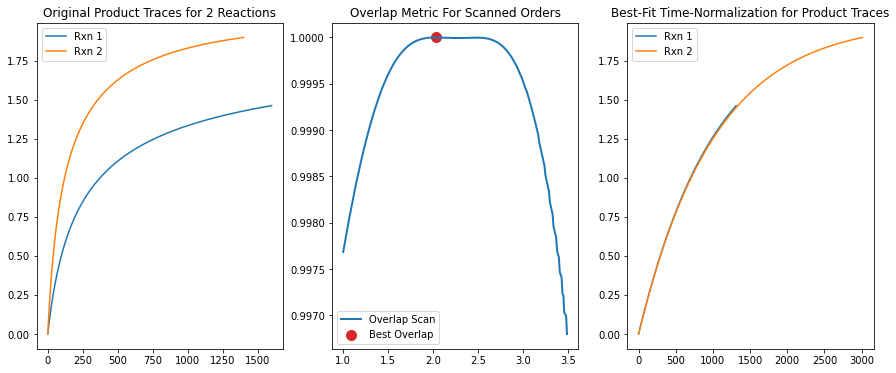

<Figure size 432x288 with 0 Axes>

In [20]:
besto, rs = order_search(time, time2, NO2, NO2_b, NO, NO_b, o_range=(1,3.5), o_step=0.01, 
               to_smooth=True, win1=None, win2=None, window_type='blackman', plot=True, figsize=(15,6))

## Now for the Second Reactant

Using autofit, we see that the order for NO is approximately 2. Let's normalize the time with this, then fit for the order of the second reactant, O$_2$.

In [43]:
t_norm_NO = normalize_time(time, NO, 2)
t_norm_NO_b = normalize_time(time2, NO_b, 2)

To fit for the remaining reactant order, we can do just a first order search to find the order that normalizes the trace to a straight line. This is handled by the `VTNA` class. We do it for both reactions. They should both produce optimal orders of 1.

In [44]:
VTNA_O2 = VTNA(t_norm_NO, NO2, O2)
VTNA_O2.smooth_data(win=30, win_type='blackman')
VTNA_O2.optimize(np.array([0]), 
                     method='nelder-mead', 
                     options={'xatol': 1e-2, 'fatol': 1e-5, 'disp': True})

Optimization terminated successfully.
         Current function value: -0.999784
         Iterations: 18
         Function evaluations: 36


array([1.00775])

In [45]:
VTNA_O2_b = VTNA(t_norm_NO_b, NO2_b, O2_b)
VTNA_O2_b.smooth_data(win=20, win_type='blackman')
VTNA_O2_b.optimize(np.array([0]), 
                     method='nelder-mead', 
                     options={'xatol': 1e-2, 'fatol': 1e-5, 'disp': True})

Optimization terminated successfully.
         Current function value: -0.999746
         Iterations: 18
         Function evaluations: 36


array([1.02375])

In [46]:
t_norm_NO_O2 = normalize_time(t_norm_NO, O2, 1)
t_norm_NO_O2_b = normalize_time(t_norm_NO_b, O2_b, 1)

As hoped for, the order of [O$_2$] is found to be $\approx$ 1 in both reactions. Now, we can plot the steps to reaction normalization for each reaction.

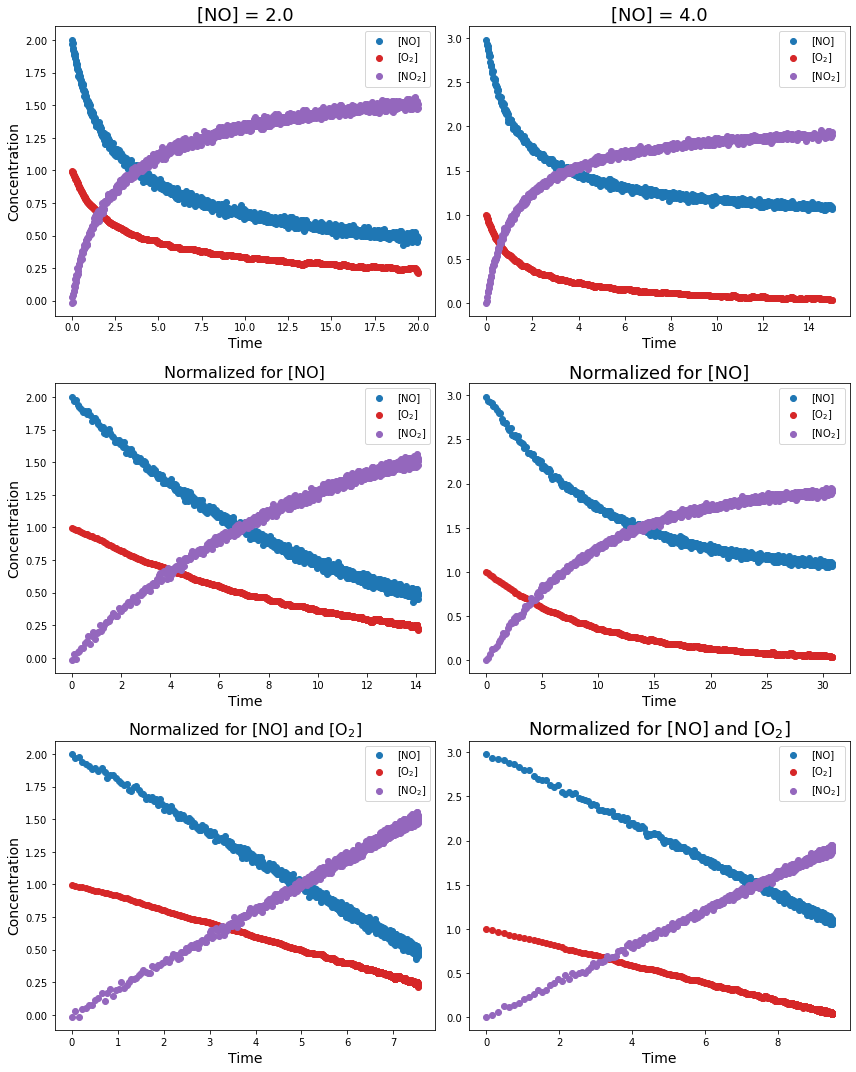

In [48]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(12, 15))

ax1.scatter(time, NO, c='tab:blue', label="[NO]")
ax1.scatter(time, O2, c='tab:red', label="[O$_2$]")
ax1.scatter(time, NO2, c='tab:purple', label="[NO$_2$]")
ax1.legend()
ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Concentration', fontsize=14)
ax1.set_title('[NO] = 2.0', fontsize=18)

ax2.scatter(time2, NO_b, c='tab:blue', label="[NO]")
ax2.scatter(time2, O2_b, c='tab:red', label="[O$_2$]")
ax2.scatter(time2, NO2_b, c='tab:purple', label="[NO$_2$]")
ax2.legend()
ax2.set_xlabel('Time', fontsize=14)
ax2.set_title('[NO] = 4.0', fontsize=18)

# First Normalization Step -- NO order 2
ax3.scatter(t_norm_NO, NO, c='tab:blue', label="[NO]")
ax3.scatter(t_norm_NO, O2, c='tab:red', label="[O$_2$]")
ax3.scatter(t_norm_NO, NO2, c='tab:purple', label="[NO$_2$]")
ax3.legend()
ax3.set_xlabel('Time', fontsize=14)
ax3.set_ylabel('Concentration', fontsize=14)
ax3.set_title('Normalized for [NO]', fontsize=16)

ax4.scatter(t_norm_NO_b, NO_b, c='tab:blue', label="[NO]")
ax4.scatter(t_norm_NO_b, O2_b, c='tab:red', label="[O$_2$]")
ax4.scatter(t_norm_NO_b, NO2_b, c='tab:purple', label="[NO$_2$]")
ax4.legend()
ax4.set_xlabel('Time', fontsize=14)
ax4.set_title('Normalized for [NO]', fontsize=18)

# Second Normalization Step -- O2 order 1
ax5.scatter(t_norm_NO_O2, NO, c='tab:blue', label="[NO]")
ax5.scatter(t_norm_NO_O2, O2, c='tab:red', label="[O$_2$]")
ax5.scatter(t_norm_NO_O2, NO2, c='tab:purple', label="[NO$_2$]")
ax5.legend()
ax5.set_xlabel('Time', fontsize=14)
ax5.set_ylabel('Concentration', fontsize=14)
ax5.set_title('Normalized for [NO] and [O$_2$]', fontsize=16)

ax6.scatter(t_norm_NO_O2_b, NO_b, c='tab:blue', label="[NO]")
ax6.scatter(t_norm_NO_O2_b, O2_b, c='tab:red', label="[O$_2$]")
ax6.scatter(t_norm_NO_O2_b, NO2_b, c='tab:purple', label="[NO$_2$]")
ax6.legend()
ax6.set_xlabel('Time', fontsize=14)
ax6.set_title('Normalized for [NO] and [O$_2$]', fontsize=18)

plt.tight_layout()
plt.show()

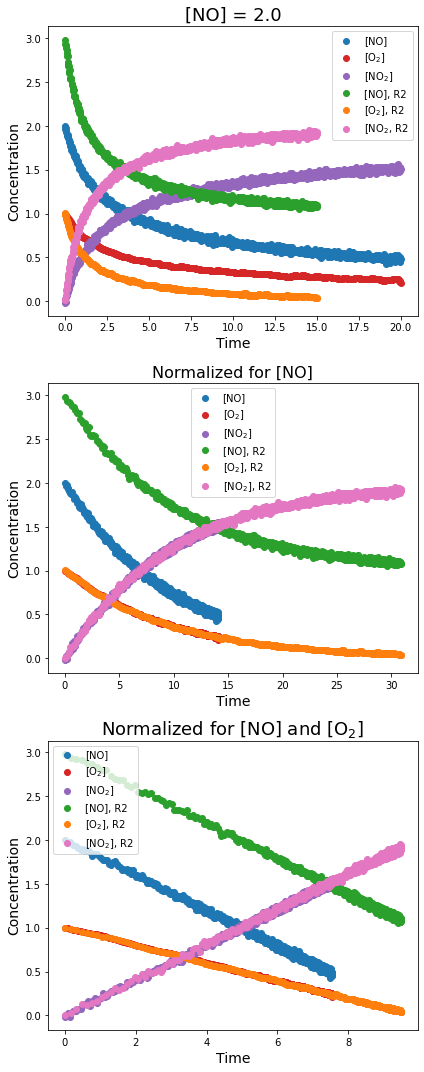

In [49]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 15))

ax1.scatter(time, NO, c='tab:blue', label="[NO]")
ax1.scatter(time, O2, c='tab:red', label="[O$_2$]")
ax1.scatter(time, NO2, c='tab:purple', label="[NO$_2$]")
ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Concentration', fontsize=14)
ax1.set_title('[NO] = 2.0', fontsize=18)

ax1.scatter(time2, NO_b, c='tab:green', label="[NO], R2")
ax1.scatter(time2, O2_b, c='tab:orange', label="[O$_2$], R2")
ax1.scatter(time2, NO2_b, c='tab:pink', label="[NO$_2$, R2")
ax1.legend()
ax1.set_xlabel('Time', fontsize=14)

# First Normalization Step -- NO order 2
ax2.scatter(t_norm_NO, NO, c='tab:blue', label="[NO]")
ax2.scatter(t_norm_NO, O2, c='tab:red', label="[O$_2$]")
ax2.scatter(t_norm_NO, NO2, c='tab:purple', label="[NO$_2$]")
ax2.set_xlabel('Time', fontsize=14)
ax2.set_ylabel('Concentration', fontsize=14)
ax2.set_title('Normalized for [NO]', fontsize=16)

ax2.scatter(t_norm_NO_b, NO_b, c='tab:green', label="[NO], R2")
ax2.scatter(t_norm_NO_b, O2_b, c='tab:orange', label="[O$_2$], R2")
ax2.scatter(t_norm_NO_b, NO2_b, c='tab:pink', label="[NO$_2$], R2")
ax2.set_xlabel('Time', fontsize=14)
ax2.legend()

# Second Normalization Step -- O2 order 1
ax3.scatter(t_norm_NO_O2, NO, c='tab:blue', label="[NO]")
ax3.scatter(t_norm_NO_O2, O2, c='tab:red', label="[O$_2$]")
ax3.scatter(t_norm_NO_O2, NO2, c='tab:purple', label="[NO$_2$]")
ax3.set_xlabel('Time', fontsize=14)
ax3.set_ylabel('Concentration', fontsize=14)
ax3.set_title('Normalized for [NO] and [O$_2$]', fontsize=16)

ax3.scatter(t_norm_NO_O2_b, NO_b, c='tab:green', label="[NO], R2")
ax3.scatter(t_norm_NO_O2_b, O2_b, c='tab:orange', label="[O$_2$], R2")
ax3.scatter(t_norm_NO_O2_b, NO2_b, c='tab:pink', label="[NO$_2$], R2")
ax3.set_xlabel('Time', fontsize=14)
ax3.set_title('Normalized for [NO] and [O$_2$]', fontsize=18)
ax3.legend()

plt.tight_layout()
plt.show()